# 

# Filterdesing und Implementierung

Hier wird beschrieben, mit welcher Software die Filter entworfen werden. Auf die genauen Spezifikationen und deren Begründung wird an anderer Stelle eingegangen. In diesem Abschnitt steht der Prozess im Fokus, welche Schritte unternommen werden, um einen Filter auf dem Pynq-Z2 zu implementieren.<br>

## Filterdesign in Matlab

Die Filter werden entsprechend der gewünschten Spezifikationen mit dem [Matlab Filter Designer](https://de.mathworks.com/help/signal/ug/introduction-to-filter-designer.html) entworfen. Für einen Biquad-Filter wird im Filter Designer ein IIR-Filter erstellt und die Koeffizienten als SOS-Matrix inklusive Gain in das Workspace exportiert. Es empfiehlt sich, das Workspace mit den Koeffizienten und dem Gain separat zu speichern, um diese bei Bedarf einfach wiederverwenden zu können. 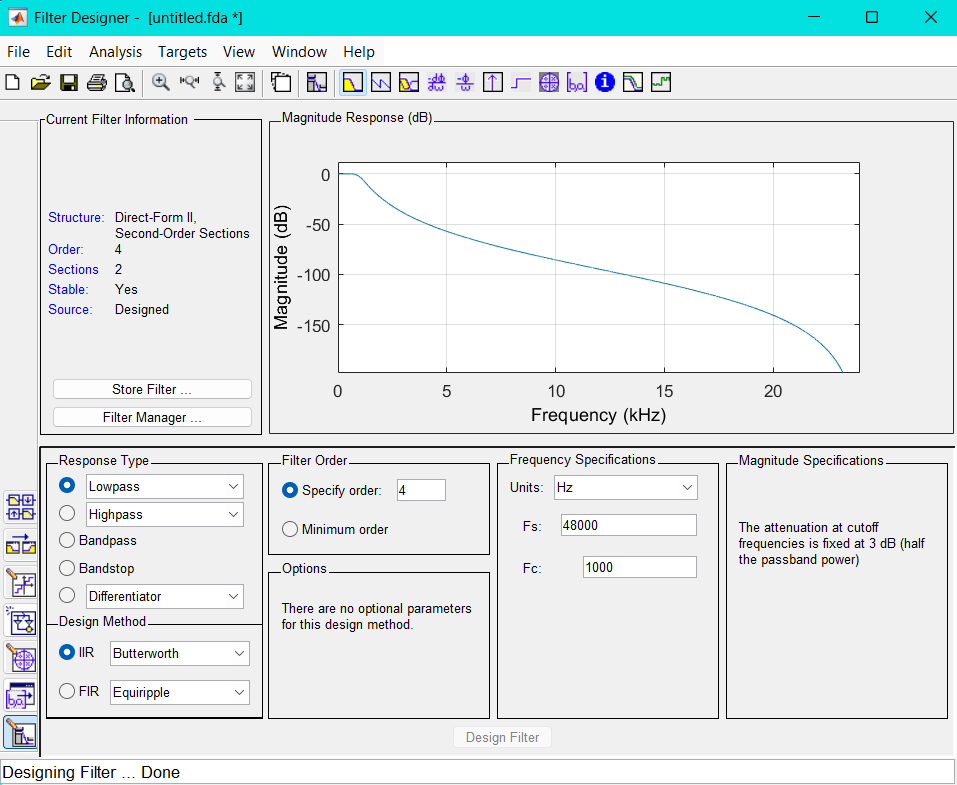 Der entworfene Filter kann in Matlab mit einem Testsignal angewendet werden, um sicherzustellen, dass seine Eigenschaften den Anforderungen entsprechen.

Für die weitere Verarbeitung werden folgende Matlab-Pakete sowie deren Abhängigkeiten benötigt: - [Simulink](https://de.mathworks.com/products/simulink.html) - [DSP System Toolbox](https://de.mathworks.com/products/dsp-system.html) - [HDL Coder](https://de.mathworks.com/products/hdl-coder.html)

Die hier verwendete Matlab-Version ist R2024b. Auch spätere Matlab-Versionen sollten kompatibel sein, sofern die erforderlichen Add-On-Pakete weiterhin unterstützt werden. <br>

## Simulink

Für die Implementierung wird das Modell des Filters in Simulink entworfen, aus welchem später mit dem HDL coder ein AXI-Stream Fähiger IP-Core für Vivado 2022.1 generiert wird. <br>

Für die Umsetzung in Simulink wurde der bereits in der DSP HDL Toolbox enthaltene Block [Biquadratic IIR (SOS) filter](https://de.mathworks.com/help/dsphdl/ref/biquadfilter.html) verwendet. Der Vorteil dieses Blocks gegebüber einer eigenen Struktur liegt darin, dass er speziell für die HDL-Codegenerierung optimiert ist und bereits eine integrierte Steuerung des valid-Signals mitbringt, ein notwendiges Element für die AXI-Stream-Implementierung. Die Filterkoeffizienten werden über das Kontextmenü direkt aus dem Matlab-Workspace geladen. Aus Gründen der numerischen Stabilität und zur Vermeidung sehr kleiner Rechenwerte wird der Gain-Faktor bereits im Vorfeld in die Zähler-Koeffizienten (Numerator) eingerechnet.<br> Es wurde der Datentyp fixdt(1,32,16) verwendet. Dieser entspricht einem signed 32-Bit-Festkommawert mit 16 Bits für die Nachkommastellen. Der Typ wurde sowohl in Simulink als auch in der späteren Hardwareimplementierung experimentell getestet und hat sich dabei als optimal herausgestellt. Er bietet ein gutes Gleichgewicht zwischen Rechengenauigkeit und Ressourceneffizienz, wobei Quantisierungsfehler minimal gehalten werden konnten. Aus diesem Grund wird dieser Datentyp fortan konsequent für alle relevanten Signalpfade verwendet.<br>

In den Einstellungen sieht dies Folgendermaßen aus:

<img src="Images\Biquad_settings1.png" width="362" /> <img src="Images\Biquad_settings2.png" width="370" />

Wie ersichtlich ist, werden die Numerator-Koeffizienten direkt aus der im Workspace gespeicherten SOS-Matrix übernommen. Zusätzlich wird der Gain-Faktor in die Numerator-Koeffizienten eingerechnet. Die Denominator-Koeffizienten (a-Koeffizienten) werden in gleicher Weise aus der SOS-Matrix bezogen.<br> Als Filterstruktur wurde Direct Form II Transponiert gewählt, da sich diese Struktur besonders gut für die Hardware-Implementierung eignet, sie benötigt weniger Speicherressourcen, insbesondere in Form von Delay-Elementen. Der Vorteil der transponierten Direktfrom 2 liegt in ihrer reduzierten Empfindlichkeit gegenüber Quantisierung und verbesserten numerischen Stabilität.<br>

Die Einstellung der Datentypen basiert auf den Standardeinstellungen der verwendeten Blöcke. In dieser Konfiguration übernimmt der Filter automatisch den Datentyp des Eingangssignals, wodurch auch die Koeffizienten intern entsprechend konvertiert werden. Um den gewünschten Datentyp explizit festzulegen, wird vor dem Eingang des Filtersystems ein Data Type Conversion-Block eingesetzt. <br> Hier wurde *fixdt(1,32,16)* als Datentyp gewählt. Dies entspricht einem signed 32 Bit breiten Weret mit 16 Bits für die Nachkommerstelle. DIeser wert wurde durch Testen in Simulink und später in hardware experimentell ermittelt und hat sich als optimaler datentyp mit minimalen quantesierungsfehlern herausgestellt und wirde fortan verwendet.<br>

Für einen Biquad-Abschnitt wird ein separater Biquadratic IIR Filter-Block aus der DSP HDL Toolbox verwendet. Diese Filterstruktur wurde in ein eigenes Subsystem eingebettet. Dies ist notwendig, da im Simulink-Modell zusätzliche Test- und Steuerungselemente integriert sind, die nicht Teil der späteren HDL-Implementierung sind. <br>

<figure>
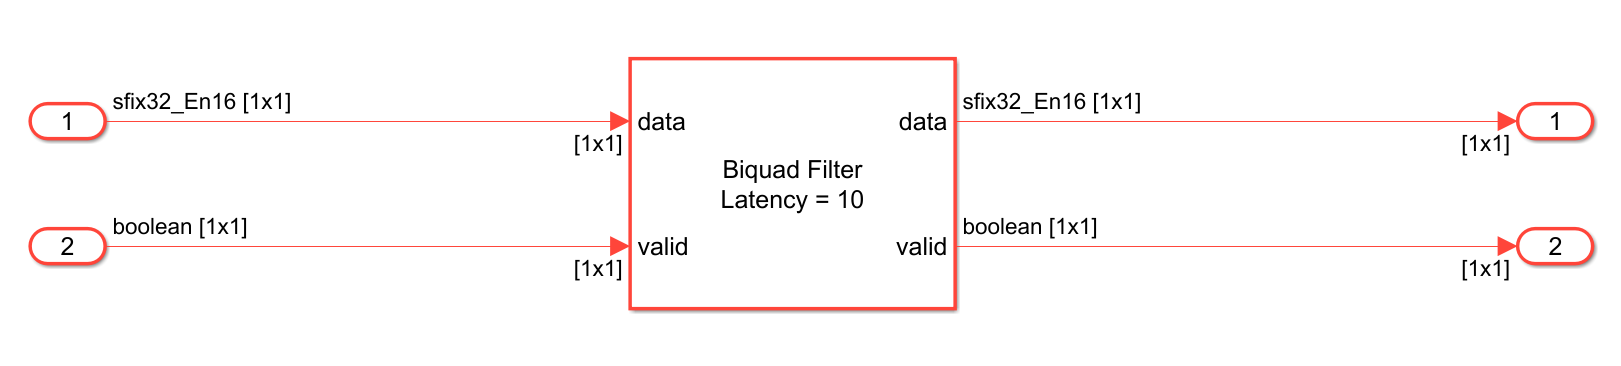
<figcaption aria-hidden="true">Matlab Filter Designer</figcaption>
</figure>

Das gesamte Simulink-Modell enthält zusätzlich zu den Filterblöcken verschiedene Komponenten zur Test- und Signalanalyse. Dazu gehören Elemente, die Testsignale aus dem Workspace einlesen, ein gültiges AXI-Stream Valid-Signal zur Simulation erzeugen sowie den Datentyp des Eingangssignals über einen Data Type Conversion-Block anpassen.<br> Zur Visualisierung sind Scopes eingebunden, die einen schnellen Überblick über den Signalverlauf ermöglichen. Darüber hinaus wird das Ausgangssignal in das Workspace zurückgeführt, um es anschließend in MATLAB weiter analysieren und verifizieren zu können.<br>

<figure>
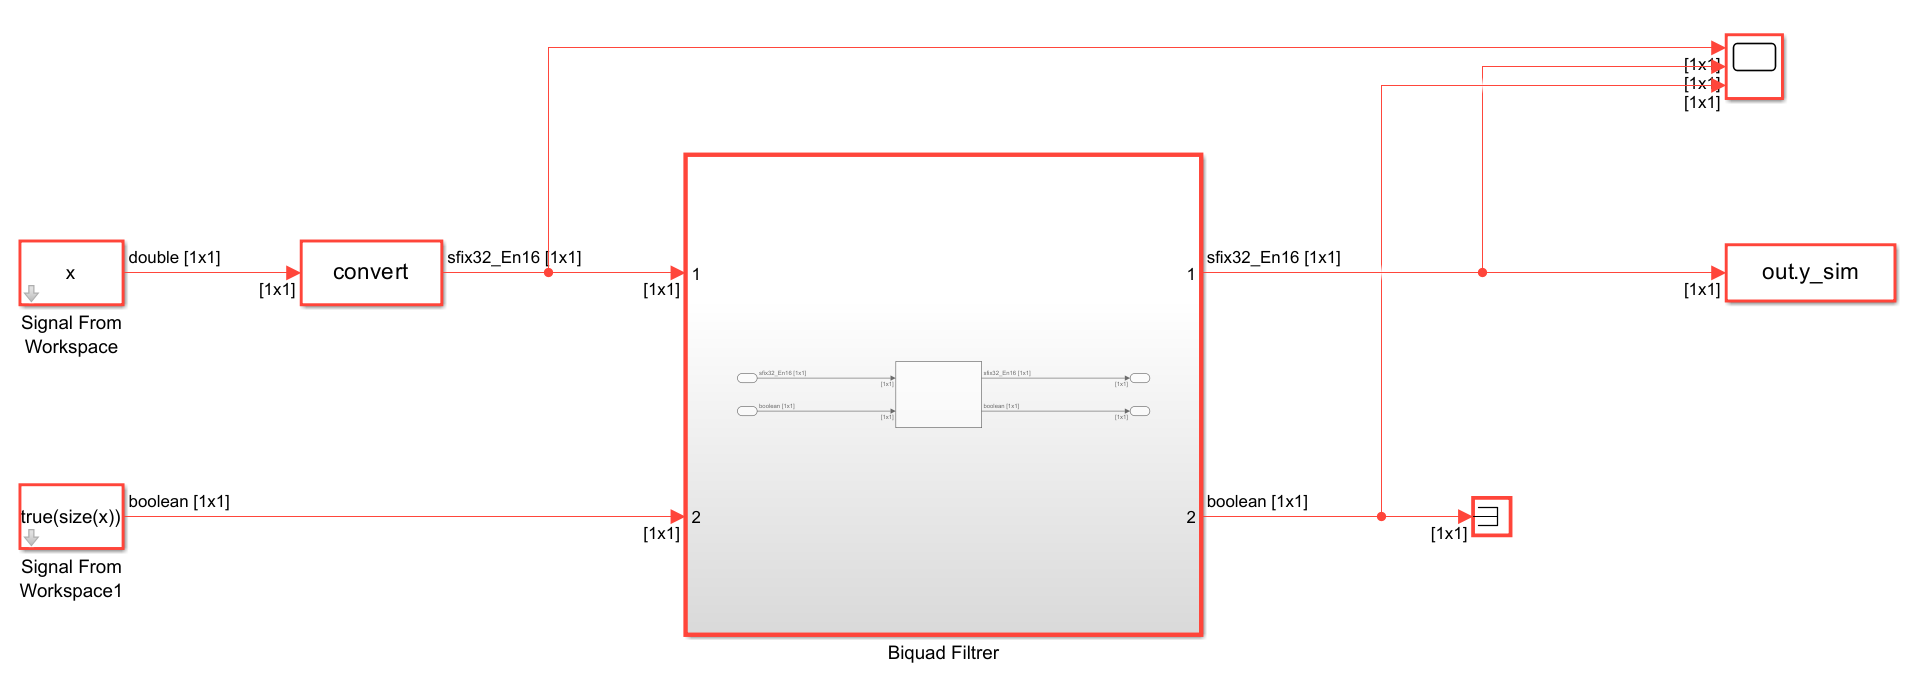
<figcaption aria-hidden="true">Matlab Filter Designer</figcaption>
</figure>

## Vorbereitung für HDL-Coder

Damit das Simulink-Modell für den HDL-Coder verwendet werden kann muss, neben den HDL-Coder kompatiblen Blöcken, einige einstellungen in Simulink selbst dirchgeführt werden.<br> Dieses Setupt lässt ich im Comand Window in Matlab austomatisch gestallten, mit der Voraussetzung, dass Vivado instaliert ist.<br> Für dieses Projekt wird Vivado 2022.1 verwendet, das dies die aktuellste Version ist die zum aktuellen Zeit von Pynq unterstützt wird. Diese Information geht aus dem [Pynq: Change Log](https://pynq.readthedocs.io/en/latest/changelog.html#version-3-0-0) aus.<br>

Das Setup in Simulink lässt sich mit der Funktion [*hdlsetup(modelname)*](https://de.mathworks.com/help/hdlcoder/ref/hdlsetup.html) ausführen. Diese Funktion konfiguriert das geöffnete Modell für den HDL-Workflow, indem sie notwendige Pfade und Einstellungen für den HDL Coder ergänzt. Sie bereitet Simulink gezielt für die Codegenerierung und FPGA-Implementierung vor.<br> Die Funktion muss pro Modell nur einmalig ausgeführt werden. Nach erfolgreicher Ausführung wird das Simulink-Modell typischerweise durch einen roten Rahmen markiert, ein Hinweis darauf, dass es für die HDL-Codegenerierung vorbereitet ist.<br>

Die Funktion [*hdlsetuptoolpath(path)*](https://de.mathworks.com/help/hdlcoder/gs/toolbox-setup.html#btp_lw0) konfiguriert den Pfad zu externen Synthese-Tools, z. B. Xilinx Vivado, die für die Synthesis, das Place & Route sowie die Bitstream-Erzeugung benötigt werden. Dieser Schritt ist erforderlich, damit die HDL Workflow Advisor-Umgebung später auf die notwendigen Werkzeuge zugreifen und einen IP-Core generieren kann.<br> Der Befehl sollte vor dem Öffnen des HDL Workflow Advisor ausgeführt werden, andernfalls kann der Toolpfad nicht korrekt übernommen werden. Es empfiehlt sich daher, diesen Befehl in ein MATLAB-Skript zu integrieren, um eine konsistente und automatisierte Projektumgebung sicherzustellen.

## HDL Workflow Advisor

Der [HDL Workflow Advisor](https://de.mathworks.com/help/hdlcoder/ug/overview-of-workflows-in-hdl-workflow-advisor.html) wird hier für die generierung eines Axi-Stream fähigen IP-Cores verwendet. Hier die vorgenommenden Einstellungen:

### 1.1 Set Target Device and Synthesis Tool

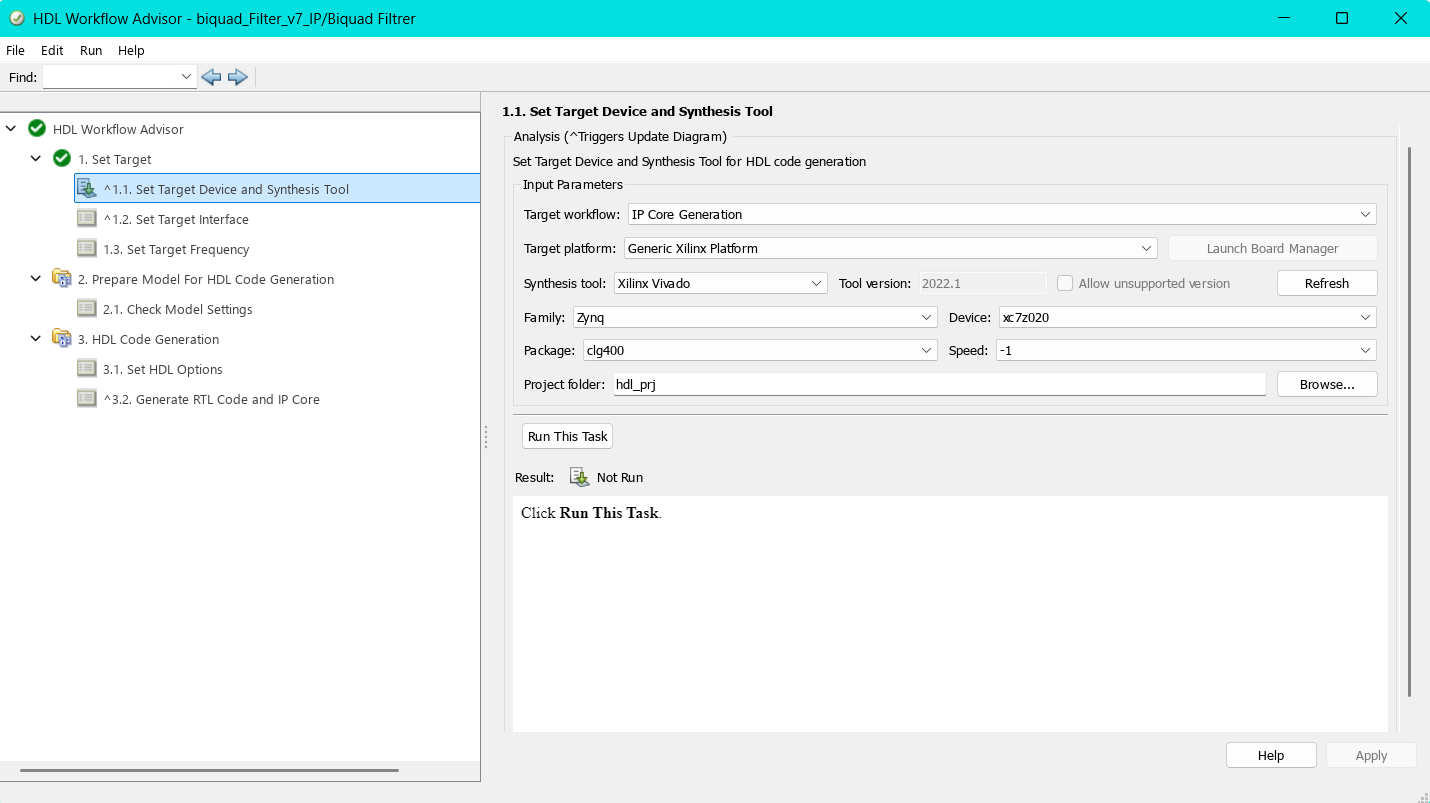<br> Hier wird die Zielhardware eingestellt. - **Target workflow:** *IP Core Generation*: Einstellung für IP-Core generierung. - **Target platform:** *Generic Xilinx Platform*: Es wird keine Boardspezifische Plattform ausgewählt, sondern eine generische Xilinx-Zielumgebung. - **Synthesis tool:** *Xilinx Vivado (Version 2022.1)*: Gibt an, dass Vivado für die Synthese und IP-Integration verwendet werden soll. - **Family, Device, Package und Speed:** *Zynq, xc7z020, clg400 und -1*: Dies sind die Notwendigen Einstellungen für den Pynq-Z2, Package und Speed wurden automatisch eingestellt. - **Project folder:** *path*: Ort an dem die generierte IP gespeichert werden soll.

### 1.2 Set Target Interface

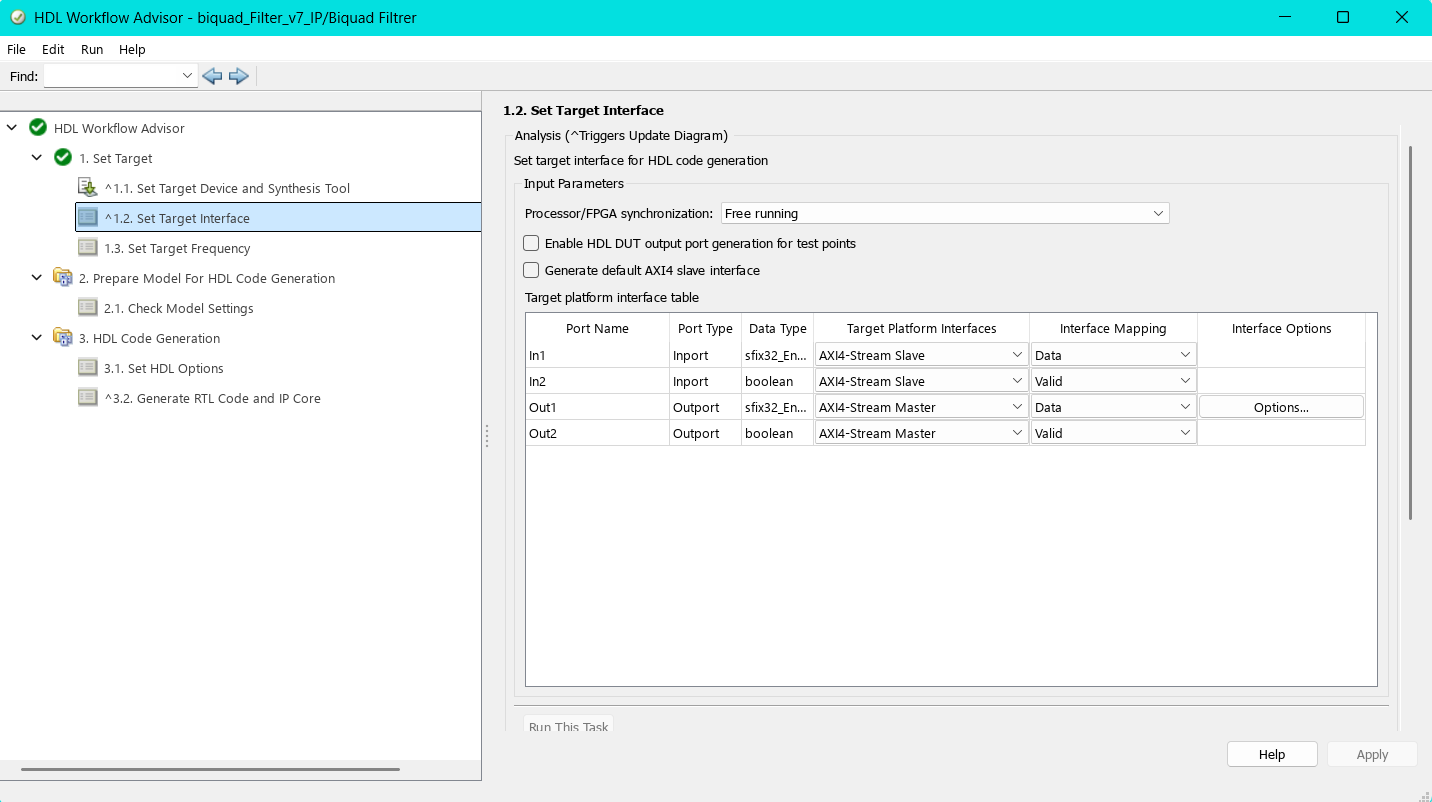<br>

In diesem Schritt werden die Ports des Simulink-Modells den Schnittstellen der AXI-Stream-Plattform zugewiesen. Die Option **Processor/FPGA Synchronization** ist auf *Free running* gesetzt, da die spätere Anwendung als kontinuierlicher Datenstrom (Streaming) ausgelegt ist. Diese Einstellung sorgt dafür, dass die Verarbeitung unabhängig vom Prozessor-Takt erfolgt.<br>

Die Übersicht in der Tabelle bietet zusätzlich einen guten Überblick über die zugewiesenen Datentypen der Ports. Bei den Signalen In1 und Out1 ist erkennbar, dass der zuvor über einen Data Type Conversion-Block eingestellte Festkommadatentyp übernommen wurde.<br>

Wichtig ist außerdem, dass die Ein- und Ausgänge für das Valid-Signal (In2 und Out2) den Datentyp boolean besitzen, da dies der AXI-Stream-Konvention entspricht.<br>

Für den Ausgang Out1 kann über die Schaltfläche Options zusätzlich die Größe des Ausgangspuffers konfiguriert werden. Standardmäßig ist dieser auf 1024 Bits eingestellt. Die größe des Ausgangspuffers wurde auf 2^16 eingestellt. Wichtig ist es die Einstellung des Ausgangspuffers zu mekren, da dieses später die Buffergröße der dma Übertragung festlegt und nicht unter- oder überschritten werden darf.<br>

Der Haken bei **Generate default AXI4 slave interface** sollte entfernt werden, sofern er gesetzt ist. Andernfalls wird automatisch eine AXI4-Lite-Schnittstelle erzeugt. Diese wird üblicherweise für die Registersteuerung verwendet.<br> Da die hier entwickelte IP jedoch für einen kontinuierlichen Datenstrom (Streaming) ausgelegt ist, ist eine Steuer-Schnittstelle nicht erforderlich. Sie würde das Design unnötig verkomplizieren und zusätzlichen Ressourcenverbrauch verursachen.<br>

### 1.3 Set Target Frequency

An dieser Stelle wird die Zielfrequenz der zu generierenden IP festgelegt. Ursprünglich war diese auf 100 MHz gesetzt. Da jedoch bei der späteren Bitstream-Erzeugung die Timing-Anforderungen nicht erfüllt werden konnten, wurde die Frequenz auf 50 MHz halbiert. Diese reduzierte Taktfrequenz zeigte im Design stabile Timingergebnisse und wurde daher für die weitere Implementierung beibehalten.

### 2.1 Check Model Settings

In diesem Schritt werden die verwendeten Simulink-Blöcke daraufhin überprüft, ob sie für die HDL-Codegenerierung geeignet sind. Zusätzlich kann ein sogenannter Industry Standard Check durchgeführt werden, der das Modell hinsichtlich Industriestandards bewertet. Dabei werden häufig Warnungen ausgegeben, insbesondere bezüglich der Namenskonventionen, wenn diese nicht den typischen Industriestandards entsprechen.<br> Für die hier verfolgte Anwendung ist es nicht erforderlich, den Industry Standard Check zu aktivieren, und es wird empfohlen, diesen nicht auszuführen, um unnötige Warnmeldungen zu vermeiden.<br>

### 3.1 Set HDL Options

**Optimaziation/General** 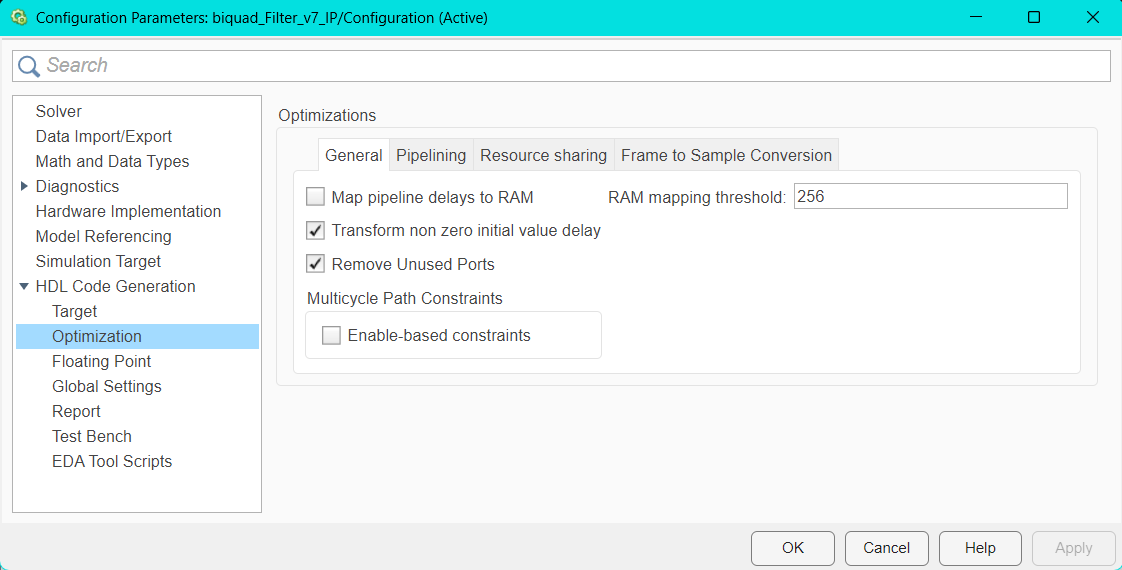<br> Die Einstellungen wurden größtenteils unverändert übernommen. Es ist jedoch wichtig sicherzustellen, dass die Option **Enable-based constraints** deaktiviert ist.<br> Diese Funktion erzeugt zusätzliche Timing-Beschränkungen auf Basis von Enable-Signalen, was bei einfacheren Designs oder kontinuierlich laufenden IPs zu unerwünschten Timingproblemen führen kann.<br>

**Optimaziation/Pipelining** 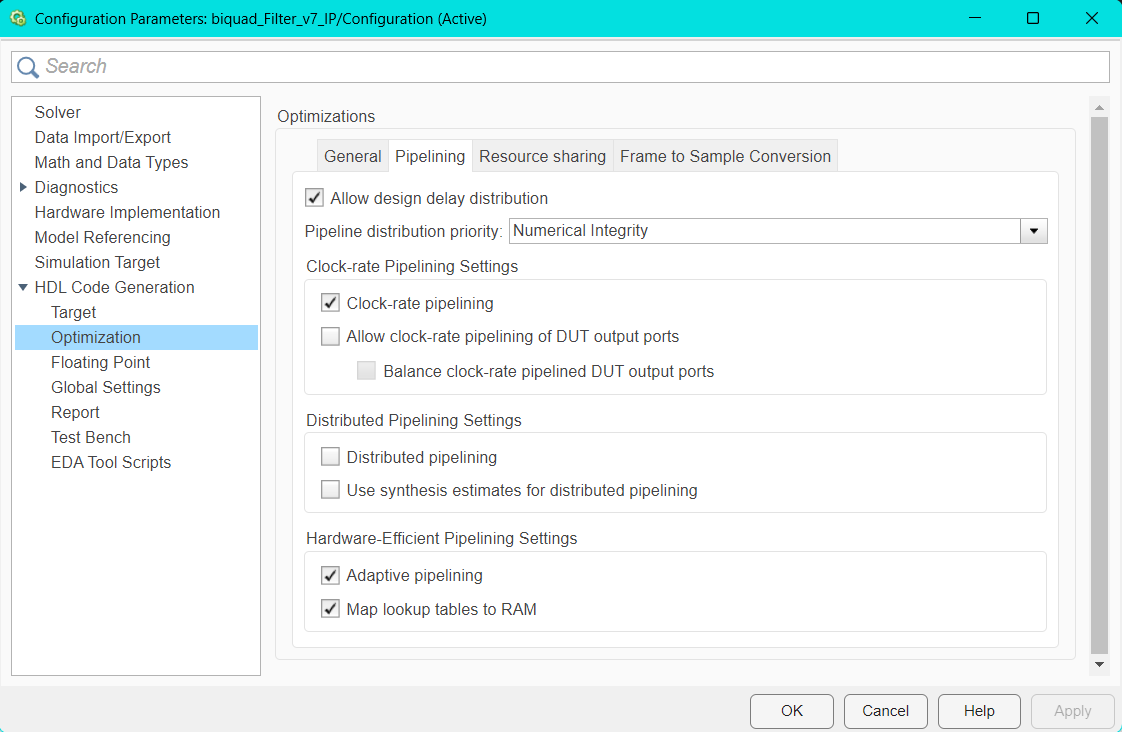<br> Auch in diesem Schritt wurden die Einstellungen weitgehend unverändert belassen. Es wird jedoch empfohlen, die Optionen „Clock-rate pipelining“ und **Adaptive pipelining** zu aktivieren.<br> Zwar lässt sich die IP auch ohne diese Optionen generieren, jedoch ermöglichen sie eine automatische Optimierung der Pipeline-Struktur. Dies kann insbesondere bei komplexeren Designs helfen, Timing-Anforderungen besser zu erfüllen und die Performance zu verbessern.<br>

**Global Settings** 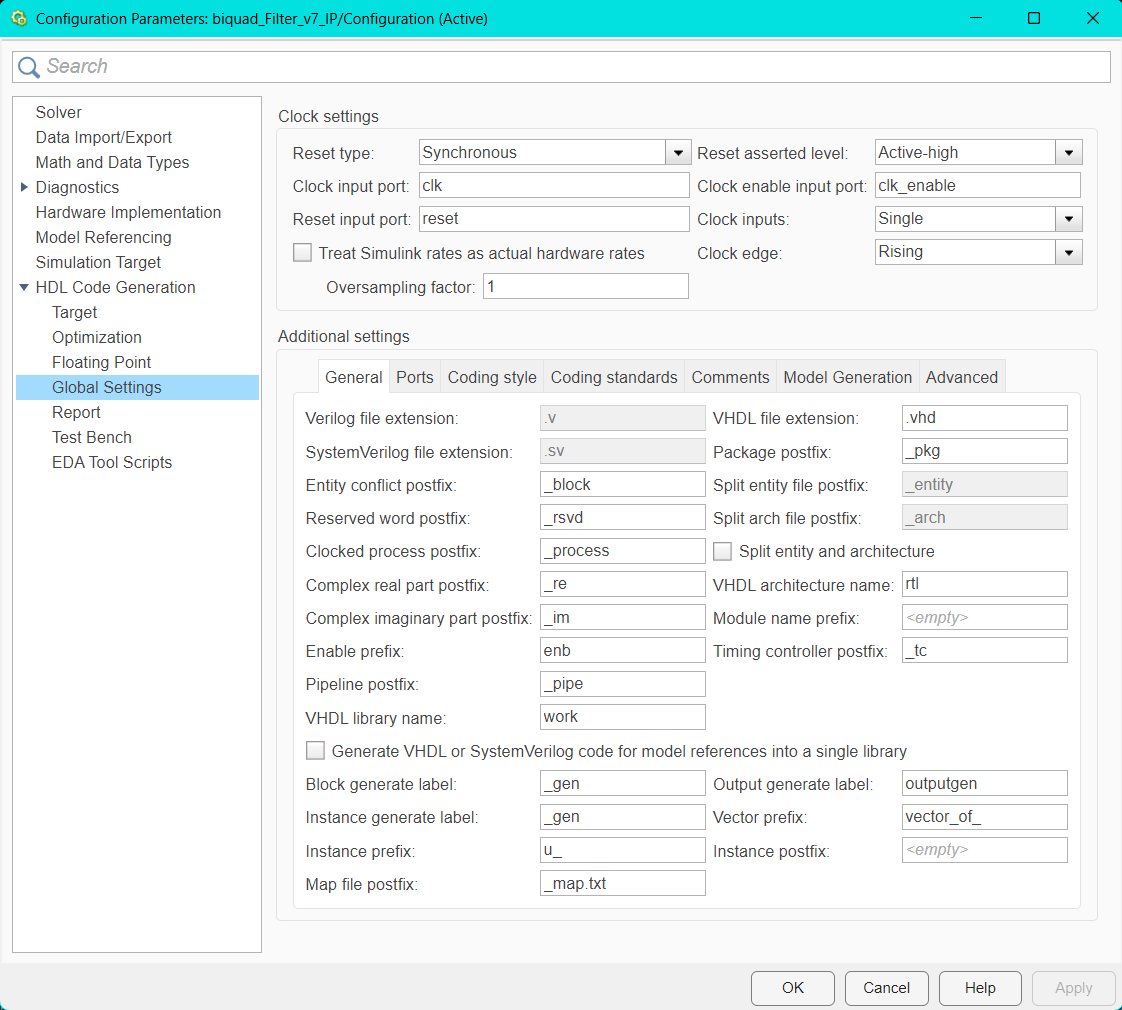<br> Die Einstellungen in diesem Schritt wurden größtenteils automatisch gewählt. Es ist jedoch unbedingt sicherzustellen, dass der **Reset type** auf *Synchronous* und der **Reset asserted level** auf *Active-high* gesetzt ist.<br> Andernfalls können beim Generieren der IP im abschließenden Bericht Warnungen oder Fehler auftreten, die auf eine inkorrekte Reset-Konfiguration hinweisen.<br>

### 3.2 Generate RTL Code and IP Core

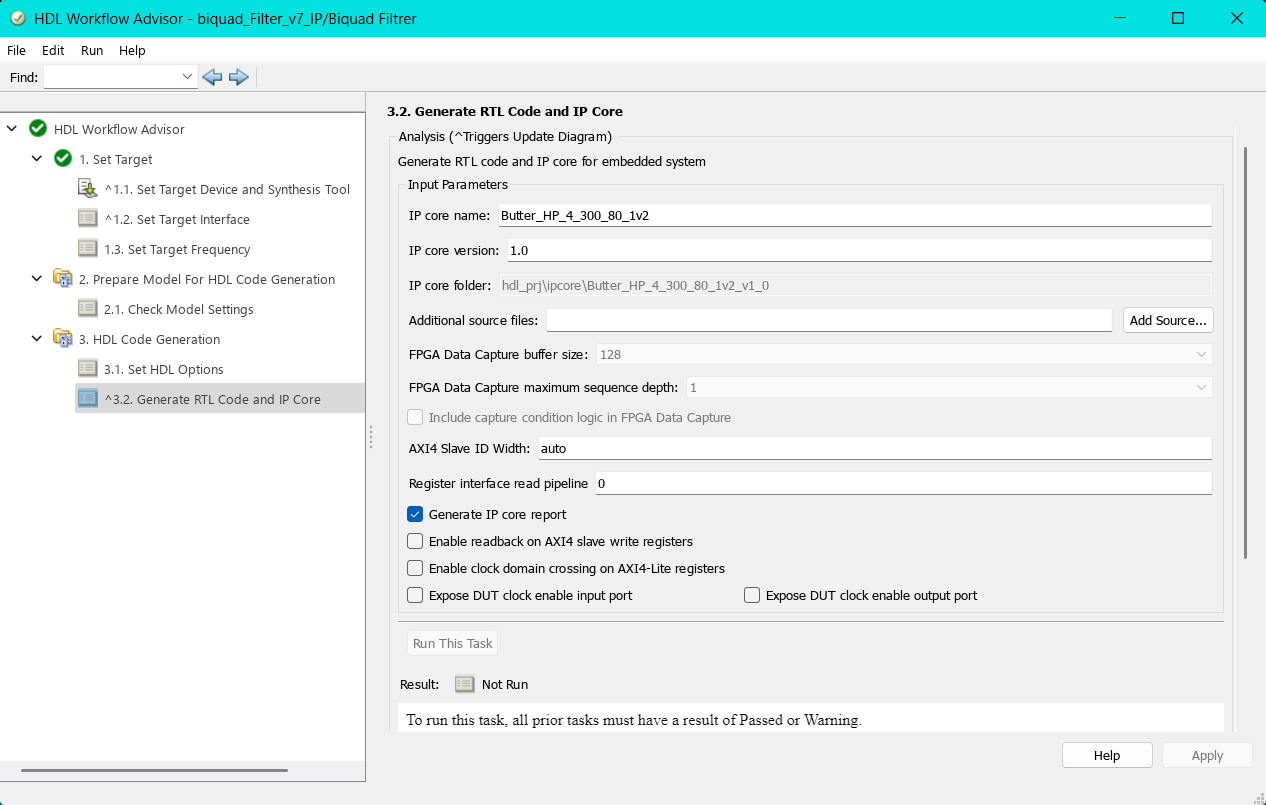<br> In diesem Schritt wurden die Einstellungen automatisch gewählt. Hier lässt sich der zu generierende IP-Core benennen und eine Versionsnummer vergeben. Für die IP sollte ein aussagekräftiger Name gewählt werden, damit sie später in Vivado leicht auffindbar ist.<br>

Um die IP zu generieren und alle vorgenommenen Einstellungen anzuwenden und zu überprüfen, klickt man mit der rechten Maustaste auf den Schritt **3.2 Generate RTL Code and IP Core** und wählt *Run to Selected Task* aus. Dadurch werden alle vorherigen Schritte automatisch durchlaufen. Tritt dabei ein Fehler auf oder wird eine Prüfung nicht bestanden, wird der Vorgang an der entsprechenden Stelle unterbrochen.<br>

Nach kurzer Generierungszeit wird die IP erstellt und ein Bericht geöffnet. Dieser enthält sowohl eventuelle Warnungen als auch den generierten HDL-Code. Der vollständige Report gibt zusätzlich einen Überblick über die verwendeten Ressourcen, beispielsweise zur Nutzung von LUTs, Flip-Flops oder Multiplikatoren.<br>

Für jeden Filter wird eine eigene IP generiert. Dabei wird jeweils dasselbe Simulink-Modell verwendet, lediglich die Koeffizienten werden entsprechend angepasst.<br>

## Vivado

Bei der Erstellung eines Vivado-Projekts für den Pynq-Z2 muss sichergestellt werden, dass das entsprechende Board im Vivado-Board-Auswahlmenü verfügbar ist. Sollte das Pynq-Z2 nicht angezeigt werden, auch nicht nach einer Aktualisierung, müssen die zugehörigen Board-Files manuell ergänzt werden. Diese lassen sich direkt aus dem offiziellen [PYNQ GitHub Repository](https://github.com/Xilinx/PYNQ/tree/master) herunterladen. Bei einer frischen Installation von Vivado 2022.1 ist das Board in der Regel bereits enthalten.<br>

Die Constraints entstammen auch aus dem [PYNQ GitHub Repository](https://github.com/Xilinx/PYNQ/tree/master). Alles, was nicht benötigt wurde auskommentiert. Die Constraints weisen unter anderem den Benötigten internen Pis Namen zu, damit diese besser nachvollzogen werden können. Es ist notwendig, dass die Namen an dem Ein- und Ausgängen aus den Constraints übernommen werden, sonst greifen die Treiber in Pynq nicht.

Für den Betrieb des Audio-Codecs auf dem Pynq-Z2 sind spezielle IP-Cores notwendig. Diese vorgefertigten IPs befinden sich ebenfalls im [PYNQ GitHub Repository](https://github.com/Xilinx/PYNQ/tree/master) und können über [*PYNQ/boards/ip/*](https://github.com/Xilinx/PYNQ/tree/master/boards/ip) ins Projekt eingebunden werden.<br> Vorgefertigte sowie auch eigens erstellte IP-Cores lassen sich in Vivado unter *Project Manager/Settings/IP/Repository* in das Projekt einbinden.<br>

Das Design orientiert sich an den offiziellen Tutorials von **Cathal McCabe** , die im AMD PYNQ-Forum verfügbar sind. Besonders hilfreich waren die Anleitungen [Creating a new hardware design for PYNQ](https://discuss.pynq.io/t/tutorial-creating-a-hardware-design-for-pynq/145) und [PYNQ DMA](https://discuss.pynq.io/t/tutorial-pynq-dma-part-1-hardware-design/3133). Teile dieser Tutorials, insbesondere grundlegende Strukturkomponenten, wurden übernommen oder angepasst.<br>

Das grundlegende Hardware-Design basiert auf dem Base-Overlay von PYNQ. Der Audio-spezifische Anteil wurde beibehalten, während nicht benötigte Komponenten entfernt wurden. Ein wesentlicher Unterschied zum ursprünglichen Base-Design liegt in der Takterzeugung. <br>

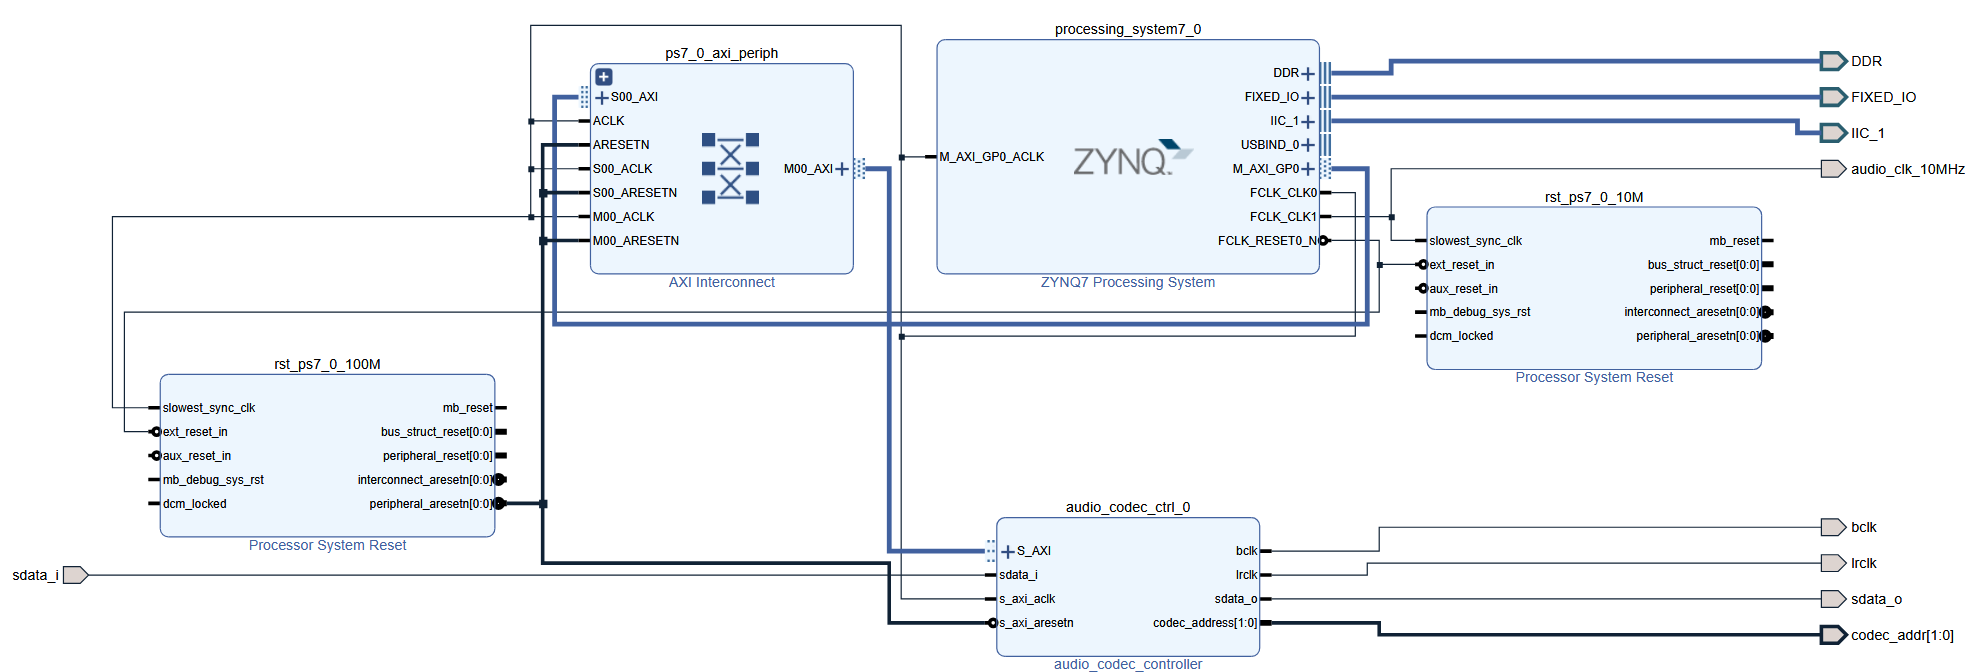<br>

Während das ursprüngliche Overlay einen Clocking Wizard verwendet, um aus einem 100 MHz-Systemtakt ein 10 MHz-Signal zu generieren, wird in der neuen Variante das 10 MHz-Taktsignal direkt aus dem Processing System (PS) bereitgestellt, inklusive eines synchronisierten Reset-Signals.<br> Diese Methode bietet den Vorteil, dass keine zusätzlichen Clock-Domain-Warnungen auftreten. Zudem wird ein vollständiger, synchroner Reset zur Verfügung gestellt, was sich positiv auf die Robustheit und das Timing des Designs auswirkt.<br>

### Processing System (PS)

<img src="Images/Vivado_PS_Settings_PS_PL_Config.png" width="370" /> <img src="Images/Vivado_PS_Settings_Clock_Config.png" width="371.6" />

Da das Design später über ein Jupyter Notebook gesteuert werden soll, genügt eine reine RTL-Implementierung nicht. Stattdessen wird das ZYNQ Processing System (PS) benötigt. Dieses übernimmt mehrere zentrale Aufgaben. Zum einen steuert es den Audio-Codec über die entsprechenden Registerzugriffe, zum anderen generiert es wichtige Taktsignale für das gesamte Design. Zudem ist der PS notwendig, um die Filter über einen AXI Direct Memory Access (AXI-DMA) anzubinden. <br> Diese AXI-DMA-Verbindung ermöglicht es, gezielt Daten zwischen dem Arbeitsspeicher des PS und den in der PL implementierten Filtern zu übertragen. Dadurch kann das Jupyter Notebook über den PS gezielt Daten an die Filter senden und deren Ausgaben empfangen.<br>

Damit der PS die korrekten Takt- und Schnittstellensignale erzeugt, muss er im Vivado-Design entsprechend konfiguriert werden. Die Konfiguration erfolgt über einen Doppelklick auf den PS-Block im Blockdesign, woraufhin der entsprechende Konfigurationsdialog geöffnet wird.<br>

**PS-PL Cinfiguration**<br> Quelle: [PYNQ DMA](https://discuss.pynq.io/t/tutorial-pynq-dma-part-1-hardware-design/3133)<br>

Diese beiden Anschlüsse dienen der Verbindung mit dem DRAM des Processing Systems (PS) und sind standardmäßig deaktiviert. Intern stehen zwei physische Zugänge zum DRAM zur Verfügung, wobei sich jeweils zwei Ports (HP0/1 und HP2/3) einen gemeinsamen Zugriff teilen. Für dieses Design werden lediglich zwei High-Performance-Ports benötigt, weshalb HP0 und HP2 aktiviert werden. Die Datenbreite (Data Width) kann auf dem Standardwert von 64 Bit belassen werden.<br>

**Peripheral I/O Pins**<br> Für die Kommunikation mit dem Audio Codec Controller wird eine I²C-Verbindung benötigt. Diese Schnittstelle lässt sich in der PS-Konfiguration unter Peripheral I/O Pins aktivieren, indem der entsprechende Haken gesetzt wird. In diesem Fall wurde ISC 1 ausgewählt, da dieser Bus für den Datenaustausch mit dem Audio Codec vorgesehen ist.<br>

**Clock Cinfiguration**<br> An dieser Stelle werden die Takt-Signale für die programmierbare Logik (PL) konfiguriert. Der Audio-Codec benötigt ein 10 MHz Taktsignal, während der Audio Codec Controller ein 100 MHz Taktsignal erfordert. Andere Frequenzen werden von dieser IP nicht unterstützt, was in Vivado durch eine entsprechende Warnung angezeigt wird. Die Filter-IPs wurden auf 50 MHz ausgelegt und benötigen daher ebenfalls ein passendes 50 MHz-Taktsignal. Alle benötigten Takte werden direkt im Processing System (PS) generiert und den jeweiligen Komponenten zugewiesen.<br>

### AXI Direct Memory Access

Quelle: [PYNQ DMA](https://discuss.pynq.io/t/tutorial-pynq-dma-part-1-hardware-design/3133)<br>

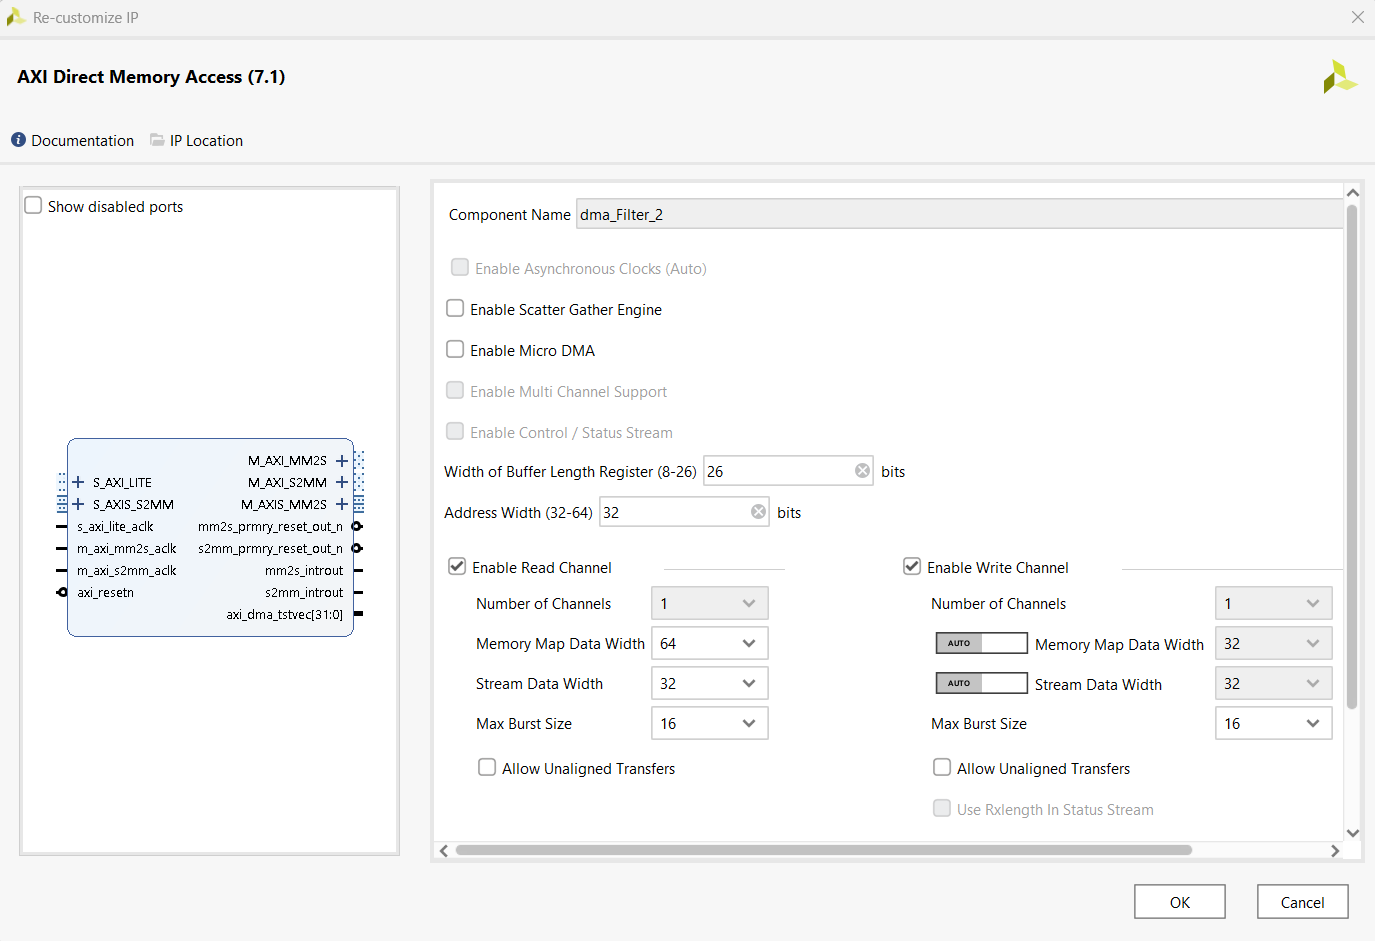<br>

Die Anbindung der Filter-IP an das Processing System (PS) erfolgt über AXI Direct Memory Access (AXI-DMA). Da im Design mehrere Filter parallel verwendet werden, werden auch vier AXI-DMA-Instanzen benötigt. Alle vier AXI-DMA-Cores werden identisch konfiguriert. Eine konsistente Namenskonvention ist hierbei essenziell, da im Jupyter Notebook später über diese Namen auf die jeweiligen DMA-Schnittstellen zugegriffen wird.<br>

Bei der Konfiguration ist besonders darauf zu achten, dass sowohl **Enable Scatter Gather Engine** als auch **Enable Micro DMA** deaktiviert werden, da diese Funktionen in diesem Design nicht benötigt werden. **Allow unaligned transfers** sollte ebenfalls deaktiviert bleiben, da diese Funktion auf dem Pynq nicht unterstützt wird. Die **Width of Buffer Length Register** wird auf den maximalen Wert von 26 gesetzt. Auch wenn dieser Wert die Anforderungen der Filter übersteigt, wurde er aus Gründen der Robustheit und zur Vermeidung zukünftiger Einschränkungen bewusst beibehalten. Ein großer Puffer verhindert zudem, dass Fehler fälschlicherweise dem DMA zugeordnet werden, obwohl sie tatsächlich im Filter auftreten.<br>

Die **Address Width** bleibt auf dem Standardwert von 32 Bit. Die „Stream Data Width“ wird entsprechend der Konfiguration der *HP0/HP2-Ports* des PS auf 64 Bit gesetzt. Auch hier gilt Lieber großzügig dimensionieren als zu knapp, was ebenfalls aus der Entwicklungsphase übernommen wurde.<br>

Die **Max Burst Size** wird auf 16 Bit gesetzt, obwohl die Burst-Funktion im eigentlichen Betrieb nicht verwendet wird. Für den Write Channel wird die Einstellung auf *Auto* belassen, wodurch automatisch die Parameter des Read-Channels übernommen werden.<br>

### Verbindungen

Vivado bietet die Möglichkeit, Blöcke automatisch anhand von vorgeschlagenen Verbindungen miteinander zu verbinden. Bei standardisierten Schnittstellen sind diese Vorschläge in der Regel korrekt und können den Designprozess deutlich beschleunigen. Dennoch sollte stets überprüft werden, ob die vorgeschlagene Verbindung tatsächlich der gewünschten entspricht.<br> Bei Verwendung dieser Funktion fügt Vivado oft automatisch unterstützende Blöcke wie beispielsweise einen *AXI Interconnect* hinzu, was zur besseren Übersichtlichkeit und Strukturierung des Designs beiträgt.<br>

Eine Ausnahme bilden jedoch die Ein- und Ausgänge, die über die Constraints-Datei (XDC) definiert sind. Für diese Signale funktioniert die automatische Verbindung nur eingeschränkt oder fehlerhaft. Daher wird empfohlen, diese Verbindungen manuell vorzunehmen, um Fehler im späteren Designverlauf zu vermeiden.<br>

**S_AXI (S_AXI_LITE)**<br> Dabei handelt es sich um die *AXI-Lite-Schnittstelle*, die für die Registersteuerung benötigt wird. Sowohl der *Audio-Codec-Controller* als auch die *AXI-DMA-Module* besitzen jeweils eine solche Verbindung. Diese werden allerdings auf unterschiedliche Clock-Frequenzen eingestellt, da sie unterschiedliche Anforderungen an die Taktung stellen:<br> - **Audio Codec Controller**: 100MHz - **Axi-DMA**: 50MHz

**M_AXI_MM2S/M_AXIS2MM**<br> Quelle: [PYNQ DMA](https://discuss.pynq.io/t/tutorial-pynq-dma-part-1-hardware-design/3133)<br>

Dies sind die Verbindungen an den HP0/2-Ports des Processing Systems (PS), über die die Daten zwischen dem BRAM und dem AXI-DMA übertragen werden. Diese Anschlüsse werden ausschließlich für die AXI-DMA-Kommunikation genutzt. Der *M_AXI_MM2S*-Port ist der *Read Channel*, und *M_AXI_S2MM* ist der *Write Channel*. Da die AXI-DMA-Module als Master fungieren, sind sie in der Lage, sowohl Lese- als auch Schreibzugriffe durchzuführen. Der PS übernimmt hierbei die Slave-Rolle. Diese Verbindungen werden bei allen vier AXI-DMA-Instanzen auf die gleiche Weise hergestellt. - **M_AXI_MM2S:** HPO, 50MHz - **M_AXI_2SMM:** HP2, 50MHz

**AXI-Stream**<br> Die Filter sowie die AXI-DMA-Module besitzen jeweils einen **S_AXIS_2SMM/AXI4_Stream-Slave** (*Slave*) und einen **M_AXIS_MM2S/AXI4_Stream-Master** (*Master*) Anschluss. Da es sich beim AXI-Stream um eine gerichtete Verbindung handelt, ist es entscheidend, dass immer ein Master-Port mit einem Slave-Port verbunden wird.<br> Diese Verbindungen müssen manuell vorgenommen werden, da Vivado diese Zuordnungen nicht automatisch erkennen kann. Nachdem die Datenpfade korrekt verbunden wurden, schlägt Vivado in der Regel automatisch eine Verbindung für die zugehörigen Taktsignale (Clock) und Reset-Signale vor.<br> Wichtig ist dabei, das richtige Taktsignal auszuwählen, in diesem Fall 50 MHz, da die Filter in dieser Taktfrequenz ausgelegt sind.<br> Sind alle Verbindungen korrekt vorgenommen, ergibt sich folgendes Bild: - *M_AXIS_MM2S (DMA) -\> AXI4_Stream-Slave (Filter)*, 50MHz - *S_AXIS_2SMM (DMA) -\> AXI4_Stream-Master (Filter)*, 50MHz

### Vollendetes Design

Sind alle Verbindungen korrekt vorgenommen, ergibt sich folgendes Blockdesign:

<figure>
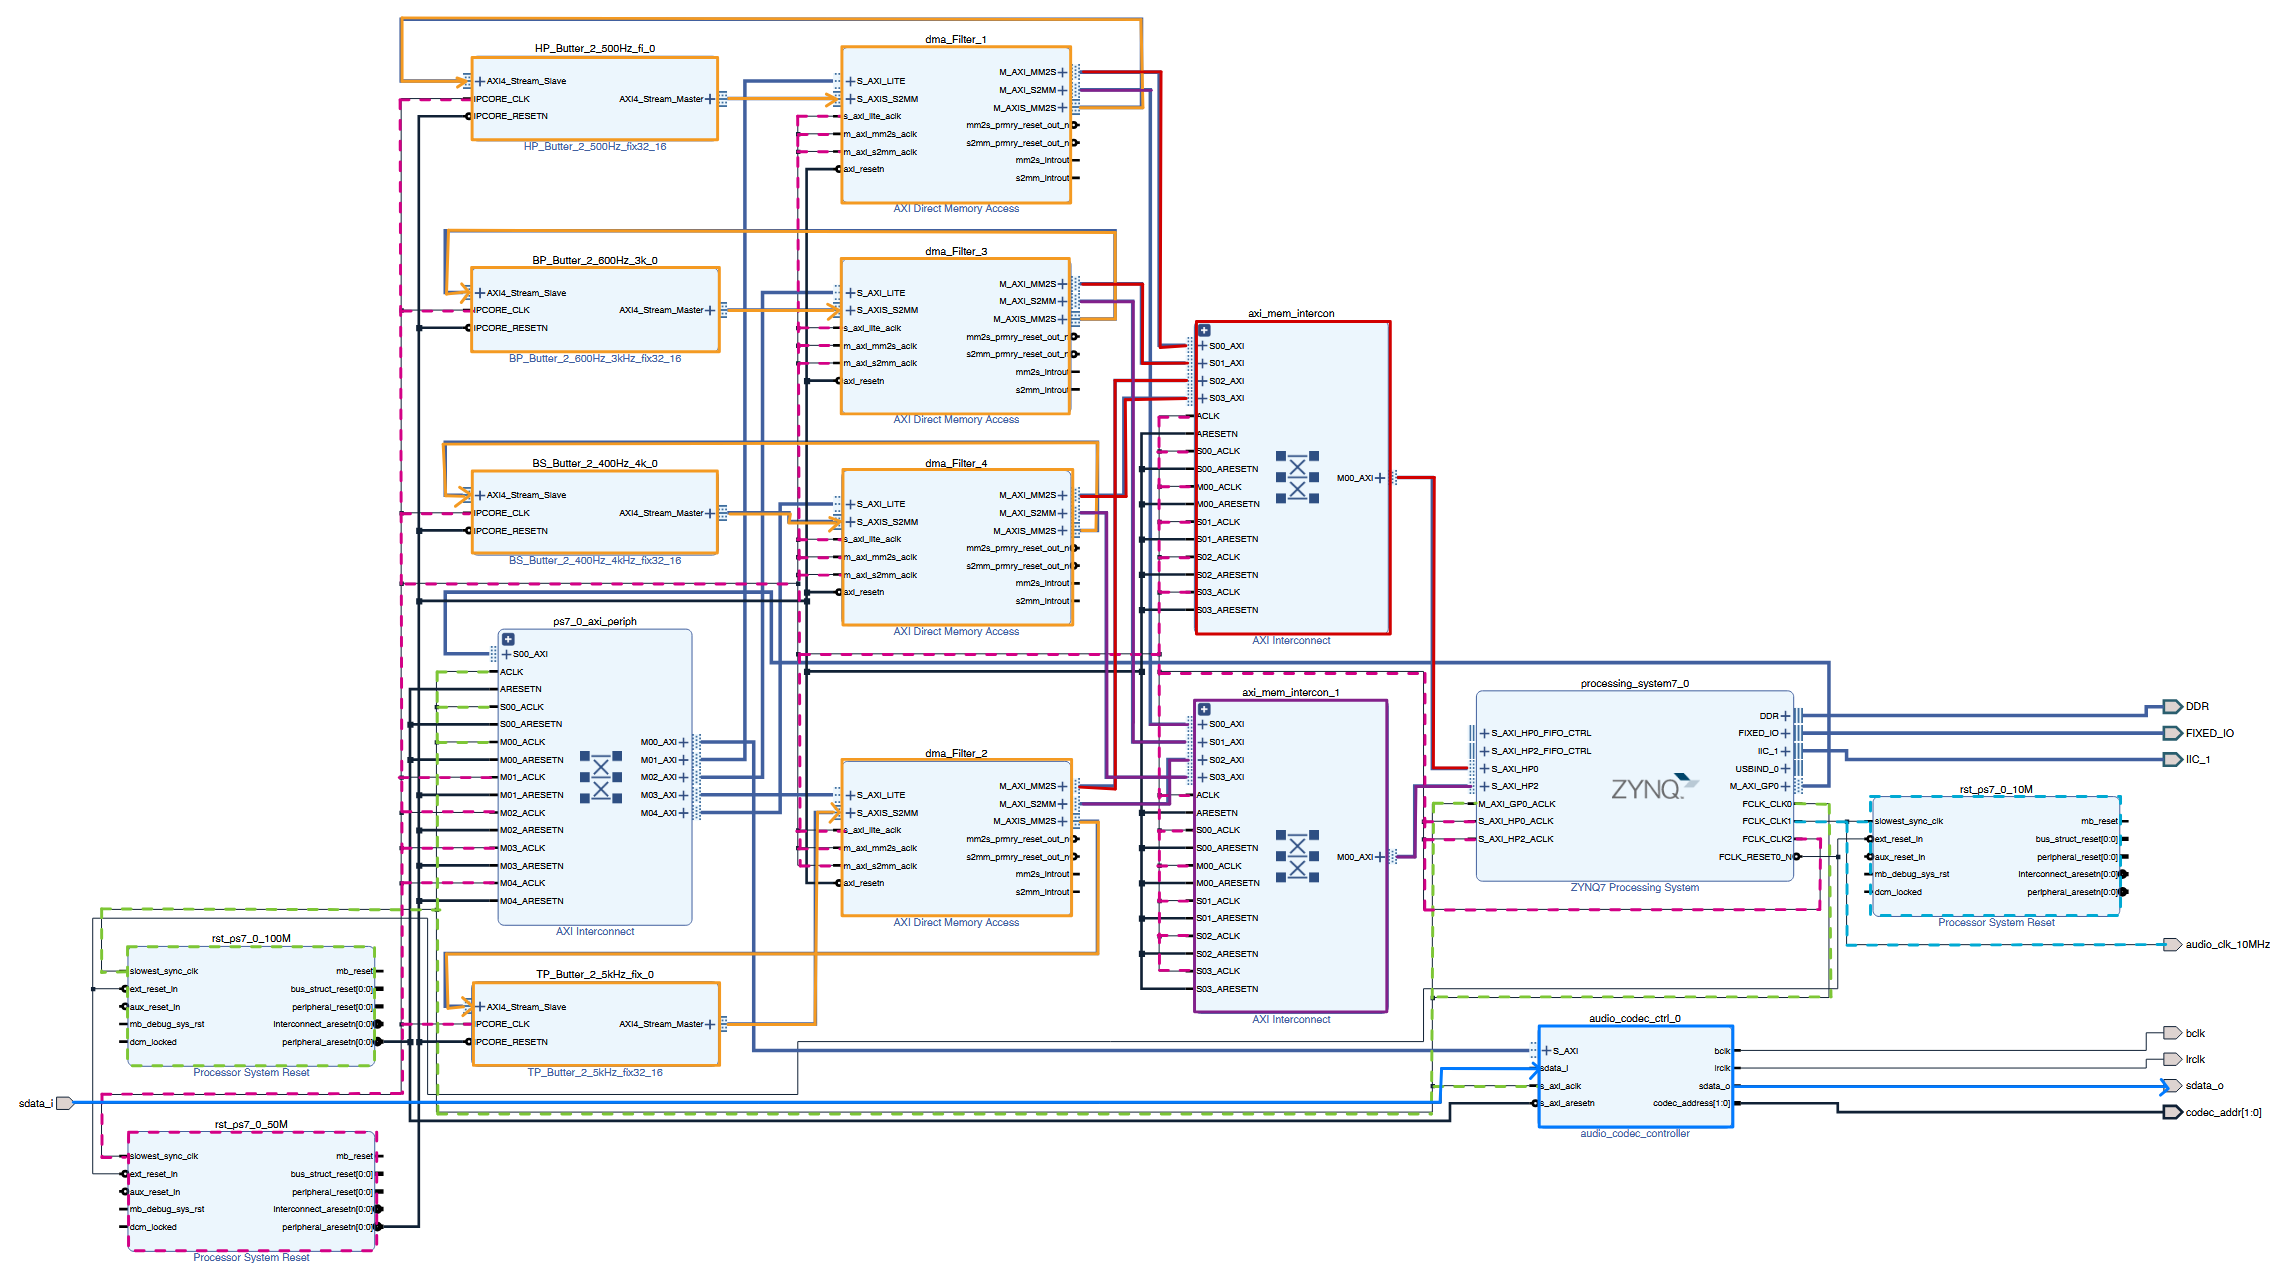
<figcaption aria-hidden="true">audio_quad_Filter_v1</figcaption>
</figure>

Die Clock-Signale sowie die wichtigsten Datenpfade wurden zusätzlich farblich hervorgehoben, um die Struktur übersichtlicher darzustellen.<br> Mit der Taste F6 kann das Design in Vivado validiert werden. Wenn dabei keine Fehler erkannt werden, kann im nächsten Schritt der Bitstream generiert werden.<br>

Am Ende bilden das Overlay die .bit und .hwh-Datei. Damit PYNQ das Overlay korrekt erkennt, müssen beide Dateien denselben Namen tragen, mit Ausnahme der Dateiendung..<br>